In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [19]:
from pandas.tseries.offsets import CustomBusinessDay
#Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 10))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = "#800000"
neutral_color = viridis_colors[4]
Custom_palette = viridis_colors

In [20]:
df = pd.read_csv('/content/DataCoSupplyChainDataset.csv', encoding='latin-1')

In [21]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [22]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [23]:
# Overview
print('rows, cols:', df.shape)

print('\ncolumns:')
print(df.columns.tolist())

print('\nNum duplicates:', df.duplicated().sum())

print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [24]:
# Data Cleaning

columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',  # identical to Order Profit Per Order
    'Product Status',     # have only one value
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

df = df.drop(columns=columns_to_drop)

df = df[df['Delivery Status'] != 'Shipping canceled']

for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst=False)
print('rows, cols', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))


rows, cols (172765, 20)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [25]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [26]:
# Value counts for categorical columns with low cardinality

for col in df.columns:
    if df[col].nunique() < 10:
        print(f"\n{col} value counts:")
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [27]:
# Calculating order processing time and delay

df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] -
    df['order date (DateOrders)']
).dt.days

df['Delay'] = (
    df['Order Processing Time'] -
    df['Days for shipment (scheduled)']
)

df['Is_Delayed'] = df['Delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

# Summary statistics
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [28]:
df['Order Profit Per Order']>0

,Order Profit Per Order
0,True
1,False
2,False
3,True
4,True
...,...
180514,True
180515,False
180516,True
180517,True


In [29]:
import numpy as np

# Profitability Flag based on Order Profit Per Order

df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0,
    'Profit',
    np.where(
        df['Order Profit Per Order'] < 0,
        'Loss',
        'Break Even'
    )
)

# Check distribution
print(df['Profitability Flag'].value_counts())

Profitability Flag
Profit        139354
Loss           32295
Break Even      1116
Name: count, dtype: int64


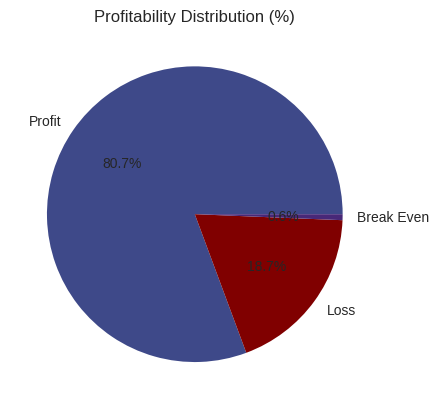

In [30]:
# Visualization of profitability distribution

profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [31]:
# Function to format currency values

def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


# Delayed orders
delayed_df = df[df['Delay'] > 0]

# Business KPIs
metrics = {}

metrics['Total Orders'] = len(df)

metrics['Late Deliveries'] = len(delayed_df)

metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)

metrics['On Time Delivery %'] = (
    1 - metrics['Late Deliveries'] / metrics['Total Orders']
) * 100

metrics['Late Delivery %'] = (
    metrics['Late Deliveries'] / metrics['Total Orders']
) * 100

metrics['Total Profit'] = format_func(
    df['Order Profit Per Order'].sum()
)

metrics['Total Loss due to Delays'] = format_func(
    df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum()
)

# Print KPIs
print("\n----- Business KPIs -----\n")

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


----- Business KPIs -----

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On Time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 3.8M $
Total Loss due to Delays: 2.1M $


##Profitability vs Delivery Time Analysis

In [32]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
      .agg(
          mean_profit='mean',
          total_profit='sum',
          order_count='count'
      )
      .reset_index()
)

print(profit_metrics.head())

   Delay  mean_profit  total_profit  order_count
0     -2    23.360134  4.875961e+05        20873
1     -1    21.604769  4.476292e+05        20719
2      0    22.249118  8.154302e+05        36650
3      1    22.333227  1.194895e+06        53503
4      2    21.128491  5.821110e+05        27551


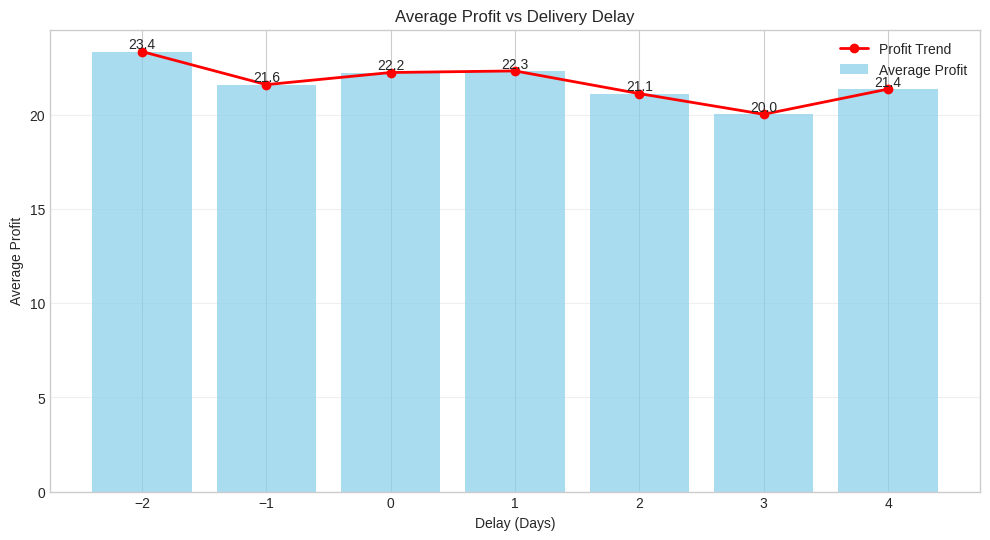

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    alpha=0.7,
    color='skyblue',
    label='Average Profit'
)

ax.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    color='red',
    marker='o',
    linewidth=2,
    label='Profit Trend'
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

ax.set_title('Average Profit vs Delivery Delay')
ax.set_xlabel('Delay (Days)')
ax.set_ylabel('Average Profit')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.show()

In [34]:
delay_distribution = (
    df['Delay']
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
      .reset_index()
)

delay_distribution.columns = ['Delay_Days', 'Percentage']

print(delay_distribution.head())

   Delay_Days  Percentage
0          -2   12.081730
1          -1   11.992591
2           0   21.213788
3           1   30.968657
4           2   15.947096


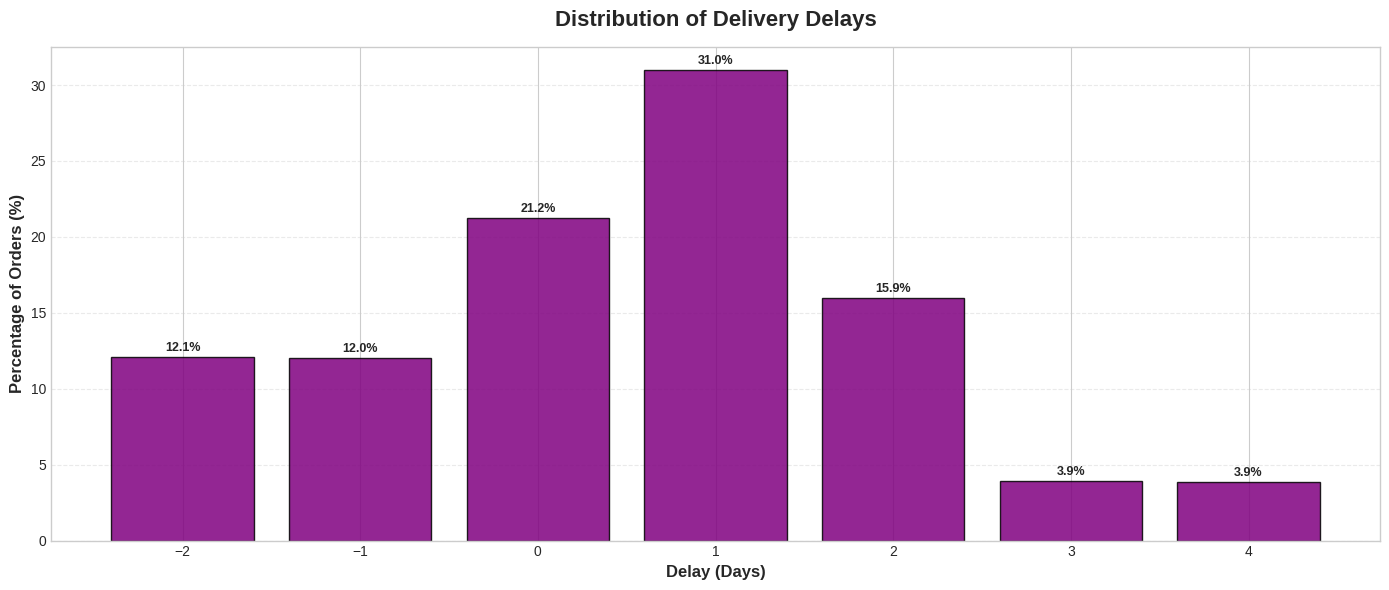

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

bars = plt.bar(
    delay_distribution['Delay_Days'],
    delay_distribution['Percentage'],
    color='purple',
    edgecolor='black',
    alpha=0.85
)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Distribution of Delivery Delays',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Delay (Days)',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Percentage of Orders (%)',
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

# **Bottelneck detection**

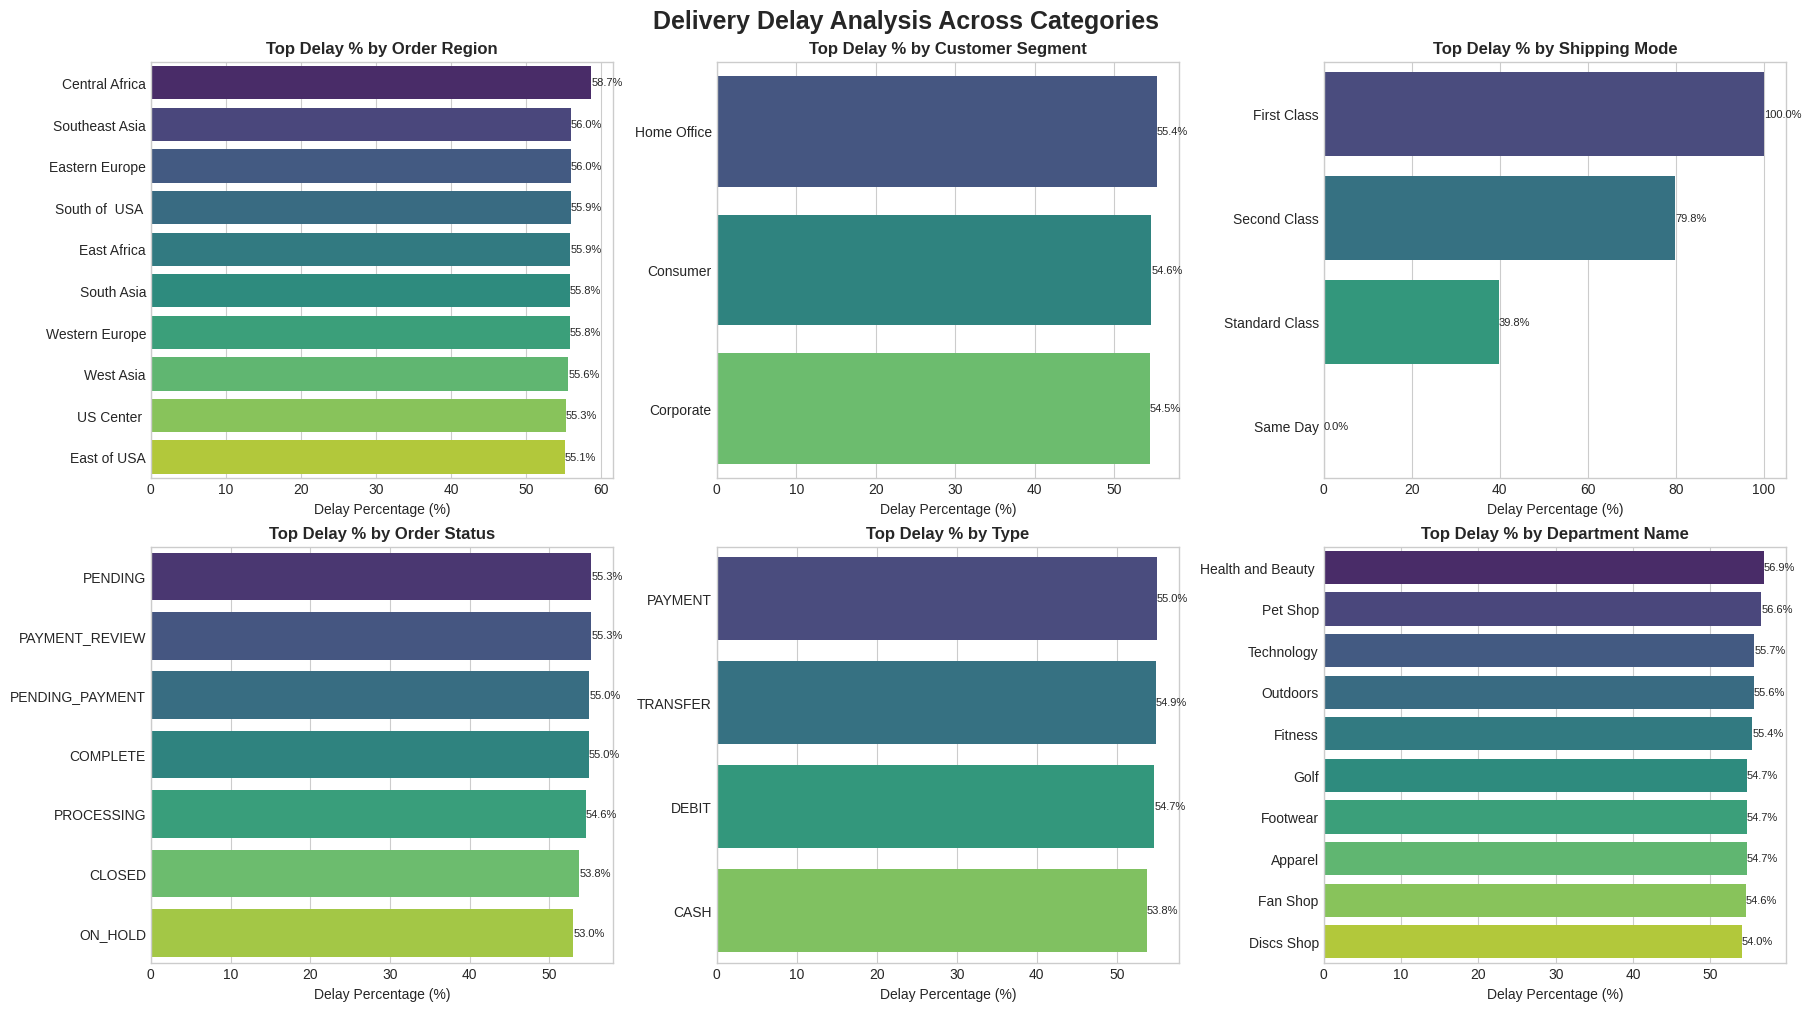

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to calculate delay percentage by category
def compute_delay_pct_by_category(category):

    cat_df = (
        df.groupby(category)
          .agg(
              total_orders=('Delay', 'count'),
              late_orders=('Is_Delayed', 'sum')
          )
          .reset_index()
    )

    cat_df['delay_pct'] = (
        cat_df['late_orders'] /
        cat_df['total_orders']
    ) * 100

    cat_df = cat_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    return cat_df


# Categories to analyze
categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

# Create subplot grid
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    constrained_layout=True
)

axes = axes.flatten()

# Plot each category
for ax, category in zip(axes, categories):

    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(
        f'Top Delay % by {category}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Delay Percentage (%)')
    ax.set_ylabel('')

    # Add labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%',
            fontsize=8
        )

plt.suptitle(
    'Delivery Delay Analysis Across Categories',
    fontsize=18,
    fontweight='bold'
)

plt.show()

# **Root Cause Analysis**

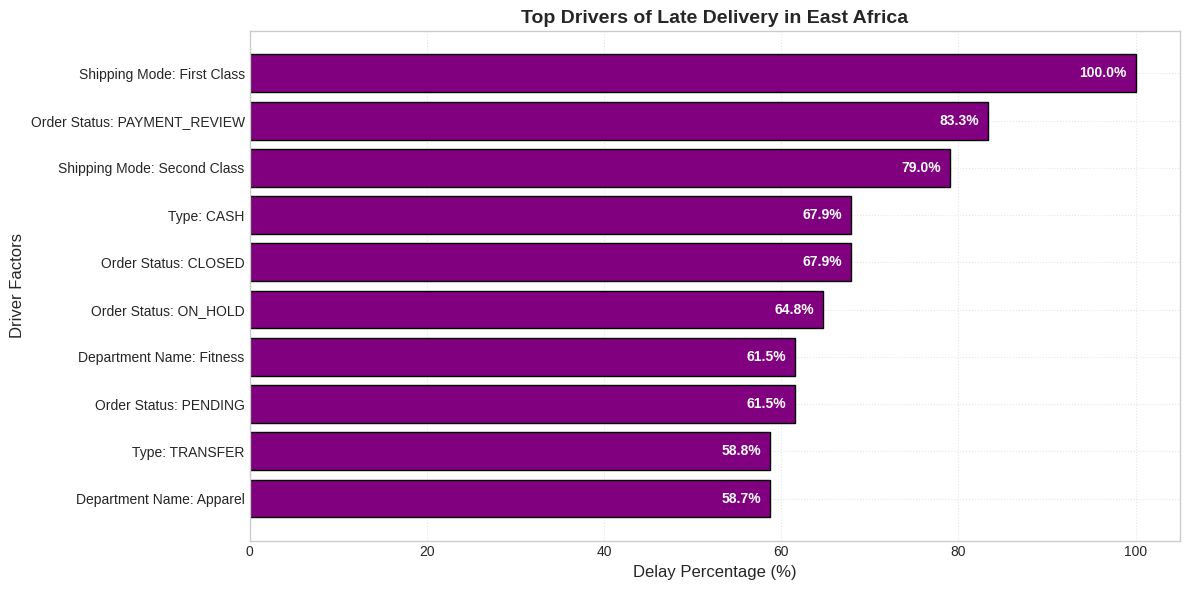

            Driver                  Factor_Level   delay_pct  avg_delay  \
0    Shipping Mode    Shipping Mode: First Class  100.000000   1.000000   
3     Order Status  Order Status: PAYMENT_REVIEW   83.333333   1.000000   
2    Shipping Mode   Shipping Mode: Second Class   79.036827   1.934844   
0             Type                    Type: CASH   67.924528   0.880503   
0     Order Status          Order Status: CLOSED   67.924528   0.880503   
2     Order Status         Order Status: ON_HOLD   64.761905   0.742857   
2  Department Name      Department Name: Fitness   61.538462   0.923077   
4     Order Status         Order Status: PENDING   61.502347   0.676056   
3             Type                Type: TRANSFER   58.752998   0.621103   
0  Department Name      Department Name: Apparel   58.730159   0.611111   

   total_orders  
0           277  
3            18  
2           353  
0           159  
0           159  
2           105  
2            13  
4           213  
3           

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Top Drivers of Late Delivery by Region

def top_drivers_for_region(region):

    # Filter region data
    df_region = df[df['Order Region'] == region].copy()

    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]

    all_factors = []

    # Calculate delay statistics for each driver
    for factor in drivers:

        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = (
            temp['late_orders'] /
            temp['total_orders']
        ) * 100

        temp['Driver'] = factor

        temp['Factor_Level'] = (
            factor + ': ' + temp[factor].astype(str)
        )

        all_factors.append(
            temp[
                [
                    'Driver',
                    'Factor_Level',
                    'delay_pct',
                    'avg_delay',
                    'total_orders'
                ]
            ]
        )

    # Combine all factors
    final_df = pd.concat(all_factors)

    # Top 10 delay drivers
    top_factors = (
        final_df
        .sort_values('delay_pct', ascending=False)
        .head(10)
    )

    # Visualization
    plt.figure(figsize=(12,6))

    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct'],
        color='purple',
        edgecolor='black'
    )

    plt.xlabel('Delay Percentage (%)', fontsize=12)
    plt.ylabel('Driver Factors', fontsize=12)

    plt.title(
        f'Top Drivers of Late Delivery in {region}',
        fontsize=14,
        fontweight='bold'
    )

    plt.grid(True, linestyle=':', alpha=0.5)

    plt.gca().invert_yaxis()

    # Add labels on bars
    for bar in bars:

        width = bar.get_width()

        plt.text(
            width - 1,
            bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            va='center',
            ha='right',
            fontsize=10,
            color='white',
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

    return top_factors


# Example Usage
top_factors = top_drivers_for_region('East Africa')

# Display top factors table
print(top_factors)

# **Time-Based Analysis**

In [51]:
# Delay % by Month, Day of Week, Hour

# Monthly delay %
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_month['delay_pct'] = (
    delay_by_month['Is_Delayed'] * 100
)

# Day-wise delay %
delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_day['delay_pct'] = (
    delay_by_day['Is_Delayed'] * 100
)

# Hour-wise delay %
delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_hour['delay_pct'] = (
    delay_by_hour['Is_Delayed'] * 100
)

print(delay_by_month.head())
print(delay_by_day.head())
print(delay_by_hour.head())

   order_month  Is_Delayed  delay_pct
0            1    0.542542  54.254150
1            2    0.546046  54.604550
2            3    0.548094  54.809390
3            4    0.545042  54.504230
4            5    0.549980  54.998022
  order_day  Is_Delayed  delay_pct
0    Friday    0.544884  54.488442
1    Monday    0.555338  55.533838
2  Saturday    0.542619  54.261937
3    Sunday    0.551524  55.152418
4  Thursday    0.547202  54.720188
   order_hour  Is_Delayed  delay_pct
0           0    0.540686  54.068641
1           1    0.554227  55.422680
2           2    0.551937  55.193735
3           3    0.541420  54.142012
4           4    0.536747  53.674683


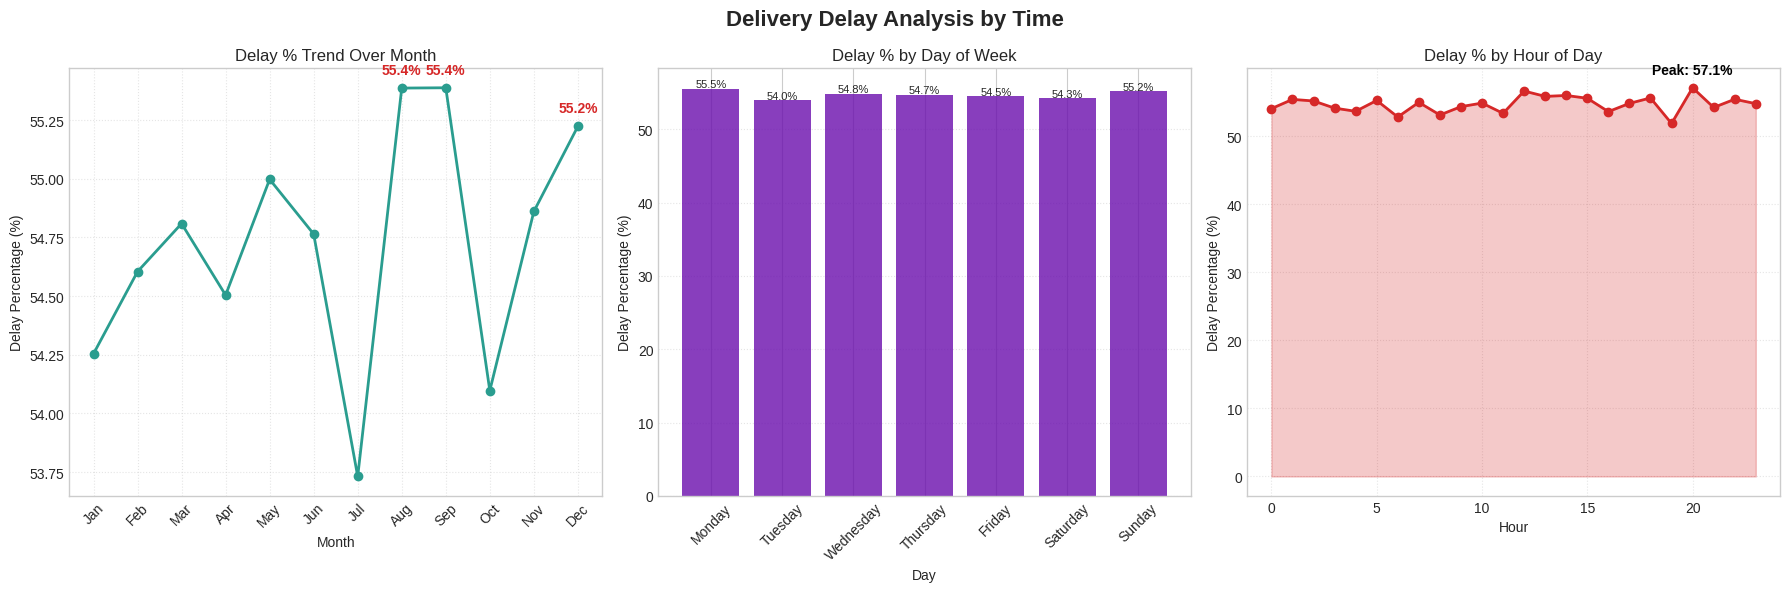

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Colors
primary_color = '#2a9d8f'
accent_color = '#6a0dad'
danger_color = '#d62828'

fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# ==========================
# Subplot 1: Delay % by Month
# ==========================

ax1.plot(
    delay_by_month['order_month'],
    delay_by_month['delay_pct'],
    marker='o',
    linewidth=2,
    color=primary_color
)

ax1.set_xticks(range(1, 13))

ax1.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Delay Percentage (%)')
ax1.set_title('Delay % Trend Over Month')

ax1.grid(
    True,
    linestyle=':',
    alpha=0.5
)

# Top 3 months annotation
top3_month = delay_by_month.nlargest(3, 'delay_pct')

for _, row in top3_month.iterrows():

    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color,
        fontweight='bold'
    )

# ==========================
# Subplot 2: Delay % by Day
# ==========================

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')

bars = ax2.bar(
    delay_by_day['order_day'],
    delay_by_day['delay_pct'],
    color=accent_color,
    alpha=0.8
)

ax2.set_title('Delay % by Day of Week')
ax2.set_xlabel('Day')
ax2.set_ylabel('Delay Percentage (%)')

ax2.tick_params(
    axis='x',
    rotation=45
)

ax2.grid(
    axis='y',
    linestyle=':',
    alpha=0.5
)

# Labels on bars
for bar in bars:

    height = bar.get_height()

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f'{height:.1f}%',
        ha='center',
        fontsize=8
    )

# ==========================
# Subplot 3: Delay % by Hour
# ==========================

ax3.plot(
    delay_by_hour['order_hour'],
    delay_by_hour['delay_pct'],
    marker='o',
    linewidth=2,
    color=danger_color
)

ax3.fill_between(
    delay_by_hour['order_hour'],
    delay_by_hour['delay_pct'],
    alpha=0.25,
    color=danger_color
)

ax3.set_title('Delay % by Hour of Day')
ax3.set_xlabel('Hour')
ax3.set_ylabel('Delay Percentage (%)')

ax3.grid(
    True,
    linestyle=':',
    alpha=0.5
)

# Peak hour annotation
peak_hour = delay_by_hour.loc[
    delay_by_hour['delay_pct'].idxmax()
]

ax3.annotate(
    f"Peak: {peak_hour['delay_pct']:.1f}%",
    (peak_hour['order_hour'], peak_hour['delay_pct']),
    textcoords='offset points',
    xytext=(0, 10),
    ha='center',
    fontsize=10,
    color='black',
    fontweight='bold'
)

# ==========================
# Final Layout
# ==========================

plt.suptitle(
    'Delivery Delay Analysis by Time',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [54]:
X = df[[
    'Type',
    'Days for shipment (scheduled)',
    'Category Name',
    'Customer Segment',
    'Department Name',
    'Order Region',
    'Shipping Mode',
    'order_month',
    'order_day',
    'order_hour'
]]

y = df['Late_delivery_risk']

In [55]:
# Identify categorical columns

cat_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print('Categorical columns:', cat_cols)

# Frequency Encoding

for col in cat_cols:

    freq = X[col].value_counts(normalize=True)

    X[f'{col}_freq'] = X[col].map(freq)

# Drop original categorical columns
X_encoded = X.drop(columns=cat_cols)

print(
    'Shape after frequency encoding:',
    X_encoded.shape
)

# Use encoded features
X = X_encoded

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'order_day']
Shape after frequency encoding: (172765, 10)
Train Shape: (138212, 10)
Test Shape : (34553, 10)


In [56]:
y.value_counts()


,count
Late_delivery_risk,
1,98977
0,73788


In [57]:
from collections import Counter
from imblearn.over_sampling import SMOTE

# Check class distribution before balancing
print("Before balancing (train):", Counter(y_train))

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)

# Check class distribution after balancing
print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(y_true, y_pred, model_name):

    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")

    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

In [59]:
rf_model_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model_balanced.fit(
    X_train_bal,
    y_train_bal
)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(
    y_test,
    y_pred_rf_balanced,
    "Random Forest Classifier"
)


Random Forest Classifier
Accuracy : 0.7247
Precision: 0.8932
Recall   : 0.59
F1 Score : 0.7106

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.91      0.74     14758
           1       0.89      0.59      0.71     19795

    accuracy                           0.72     34553
   macro avg       0.76      0.75      0.72     34553
weighted avg       0.78      0.72      0.72     34553



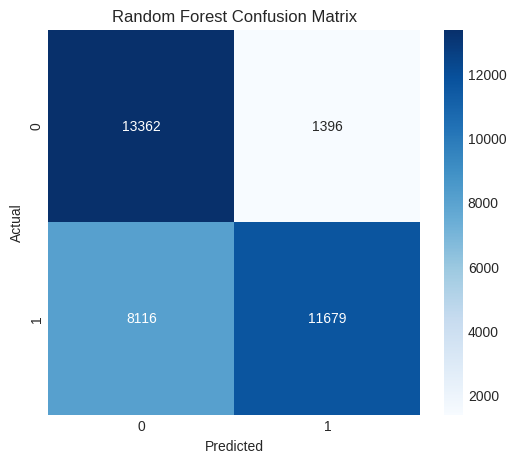

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_rf_balanced
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [61]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model_balanced.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance.head(10))

                         Feature  Importance
8             Shipping Mode_freq    0.398725
0  Days for shipment (scheduled)    0.384575
2                     order_hour    0.099297
9                 order_day_freq    0.038750
3                      Type_freq    0.022695
4             Category Name_freq    0.020508
7              Order Region_freq    0.014365
6           Department Name_freq    0.010238
1                    order_month    0.006138
5          Customer Segment_freq    0.004709


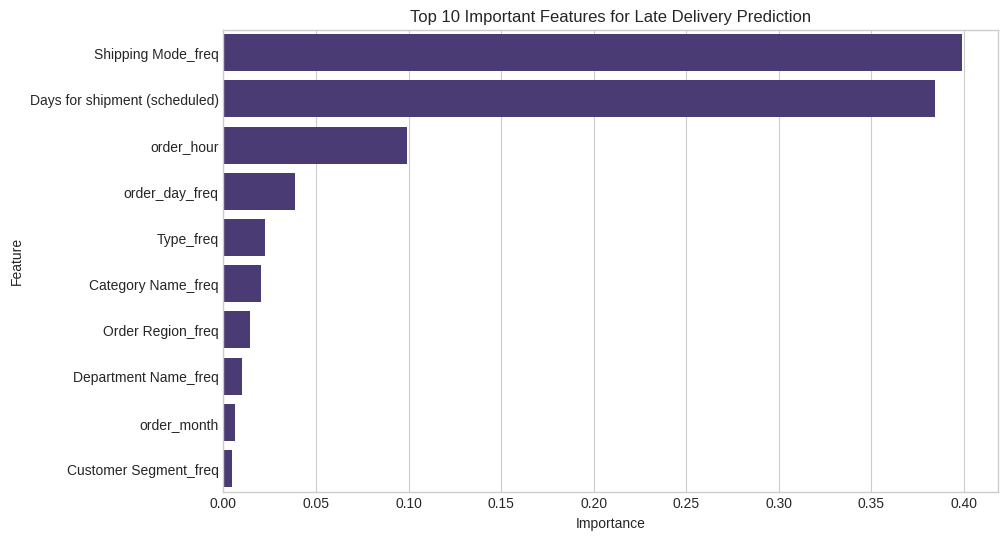

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features for Late Delivery Prediction')

plt.show()